Loading data


In [7]:
from pybalmorel import MainResults

res = MainResults(
    files=["MainResults_Base_With_C02_CAP.gdx", "MainResults_Scenario1.gdx"],
    paths=[".", "."],
    scenario_names=["Base", "Scenario1"],
    system_directory="C:\\GAMS\\53"
)
print(res)

Loading MainResults_Base_With_C02_CAP.gdx
Loading MainResults_Scenario1.gdx


# Energy mix: base vs scenario 1

Years used: ['2030', '2040', '2050']


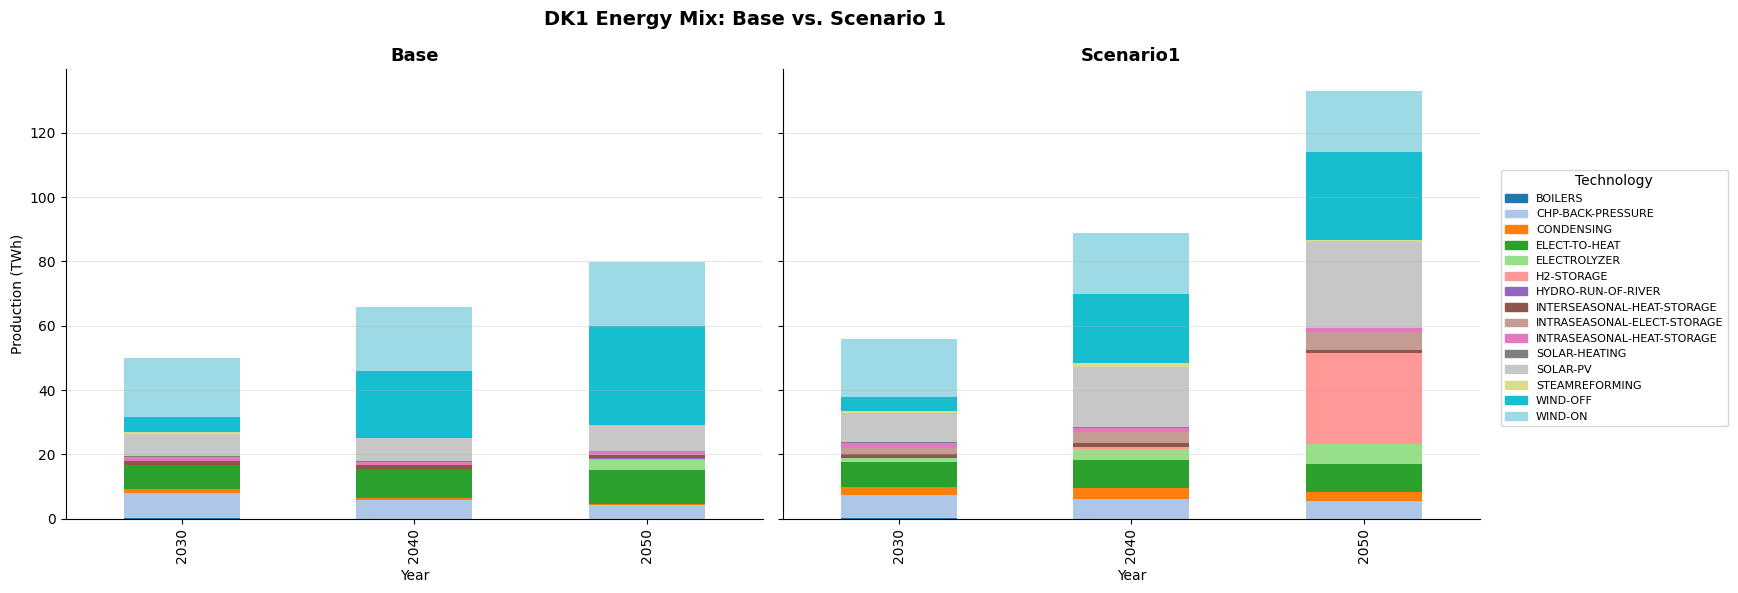

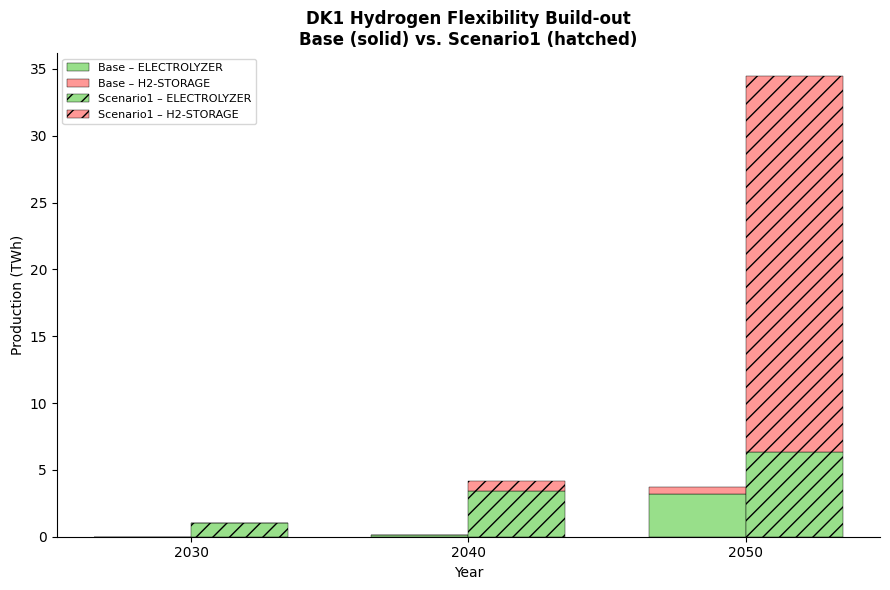

C:\Users\mulem\AppData\Local\Temp\ipykernel_26372\2758299614.py:83: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d.loc[d['is_RE'], 'Value'].sum() / d['Value'].sum() * 100)


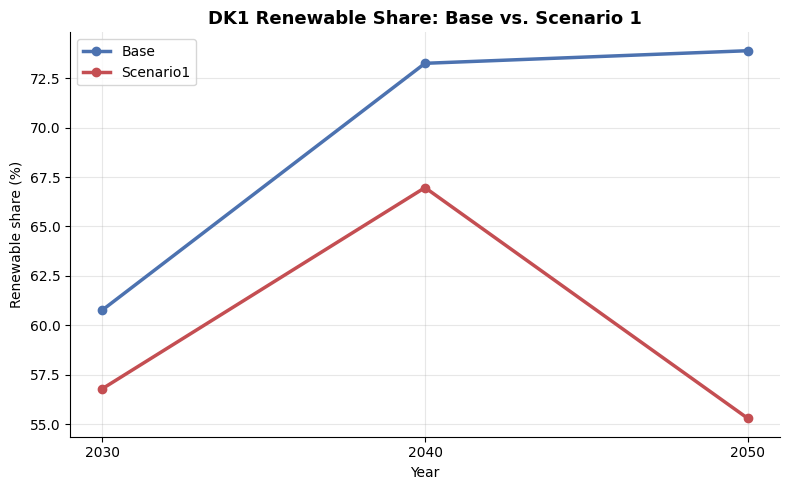

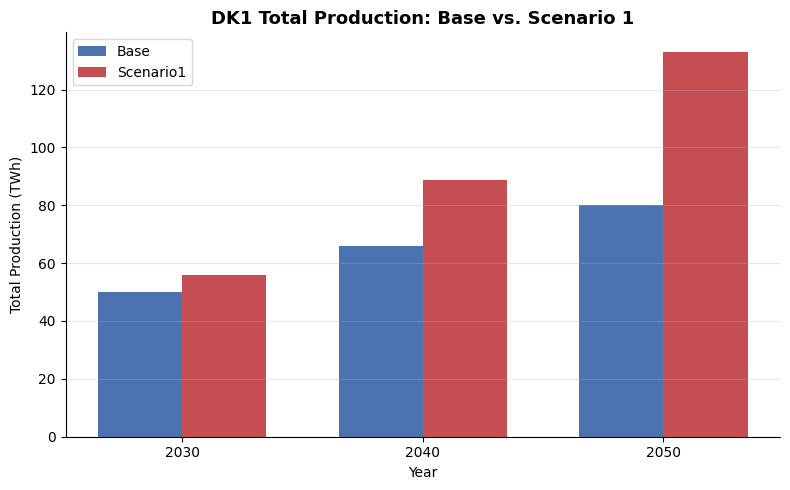

Found symbol: X_CAP_YCR
['Scenario', 'Year', 'Country', 'From', 'To', 'Category', 'Unit', 'Value']


In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------
# 0. Pull data + align years across scenarios
# ---------------------------------------------------------
pro = res.get_result('PRO_YCRAGF')

scenarios = ['Base', 'Scenario1']
colors_scen = {'Base': '#4C72B0', 'Scenario1': '#C44E52'}

# only keep years present in BOTH scenarios
common_years = sorted(set(pro.loc[pro['Scenario']=='Base','Year']) &
                       set(pro.loc[pro['Scenario']=='Scenario1','Year']))
print('Years used:', common_years)

pro = pro[pro['Year'].isin(common_years)]
dk1 = pro[pro['Region'] == 'DK1']

all_techs = sorted(dk1['Technology'].unique())
cmap = plt.get_cmap('tab20', len(all_techs))
color_map = {t: cmap(i) for i, t in enumerate(all_techs)}

# ===========================================================
# PLOT 1 — DK1 energy mix, Base vs Scenario1
# ===========================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for ax, scen in zip(axes, scenarios):
    sub = dk1[dk1['Scenario'] == scen]
    pivot = sub.groupby(['Year', 'Technology'])['Value'].sum().unstack().reindex(columns=all_techs, fill_value=0)
    pivot.plot(kind='bar', stacked=True, ax=ax, color=[color_map[t] for t in pivot.columns], legend=False)
    ax.set_title(scen, fontsize=13, fontweight='bold')
    ax.set_xlabel('Year'); ax.set_ylabel('Production (TWh)')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

handles = [plt.Rectangle((0,0),1,1, color=color_map[t]) for t in all_techs]
fig.legend(handles, all_techs, loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8, title='Technology')
plt.suptitle('DK1 Energy Mix: Base vs. Scenario 1', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('1_dk1_energy_mix.png', dpi=200, bbox_inches='tight')
plt.show()

# ===========================================================
# PLOT 2 — Flexibility build-out: Electrolyzer + H2-storage, DK1
# ===========================================================
flex_techs = ['ELECTROLYZER', 'H2-STORAGE']
flex = dk1[dk1['Technology'].isin(flex_techs)]
flex_pivot = flex.groupby(['Scenario', 'Year', 'Technology'])['Value'].sum().unstack('Technology').fillna(0)

fig, ax = plt.subplots(figsize=(9, 6))
width = 0.35
x = range(len(common_years))

for i, scen in enumerate(scenarios):
    bottom = [0] * len(common_years)
    for tech in flex_techs:
        vals = [flex_pivot.loc[(scen, y), tech] if (scen, y) in flex_pivot.index else 0 for y in common_years]
        offset = [xi + (i - 0.5) * width for xi in x]
        ax.bar(offset, vals, width=width, bottom=bottom,
               label=f'{scen} – {tech}' if i == 0 or scen == 'Scenario1' else None,
               color=color_map.get(tech), edgecolor='black', linewidth=0.3,
               hatch='' if scen == 'Base' else '//')
        bottom = [b + v for b, v in zip(bottom, vals)]

ax.set_xticks(list(x)); ax.set_xticklabels(common_years)
ax.set_xlabel('Year'); ax.set_ylabel('Production (TWh)')
ax.set_title('DK1 Hydrogen Flexibility Build-out\nBase (solid) vs. Scenario1 (hatched)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('2_dk1_flexibility.png', dpi=200, bbox_inches='tight')
plt.show()

# ===========================================================
# PLOT 3 — Renewable share (%) over time, DK1
# ===========================================================
renewables = ['WIND-ON', 'WIND-OFF', 'SOLAR-PV', 'SOLAR-HEATING', 'HYDRO-RUN-OF-RIVER', 'HYDRO-RESERVOIRS']

share = (
    dk1.assign(is_RE=dk1['Technology'].isin(renewables))
    .groupby(['Scenario', 'Year'])
    .apply(lambda d: d.loc[d['is_RE'], 'Value'].sum() / d['Value'].sum() * 100)
    .reset_index(name='RE_share')
)

fig, ax = plt.subplots(figsize=(8, 5))
for scen in scenarios:
    sub = share[share['Scenario'] == scen].sort_values('Year')
    ax.plot(sub['Year'], sub['RE_share'], marker='o', linewidth=2.5, label=scen, color=colors_scen[scen])

ax.set_xlabel('Year'); ax.set_ylabel('Renewable share (%)')
ax.set_title('DK1 Renewable Share: Base vs. Scenario 1', fontsize=13, fontweight='bold')
ax.legend(); ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('3_dk1_re_share.png', dpi=200, bbox_inches='tight')
plt.show()

# ===========================================================
# PLOT 4 — Total DK1 production: Base vs Scenario1 (simple headline number)
# ===========================================================
total = dk1.groupby(['Scenario', 'Year'])['Value'].sum().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
width = 0.35
x = range(len(common_years))
for i, scen in enumerate(scenarios):
    vals = [total.loc[(total['Scenario']==scen) & (total['Year']==y), 'Value'].sum() for y in common_years]
    offset = [xi + (i - 0.5) * width for xi in x]
    ax.bar(offset, vals, width=width, label=scen, color=colors_scen[scen])

ax.set_xticks(list(x)); ax.set_xticklabels(common_years)
ax.set_xlabel('Year'); ax.set_ylabel('Total Production (TWh)')
ax.set_title('DK1 Total Production: Base vs. Scenario 1', fontsize=13, fontweight='bold')
ax.legend(); ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('4_dk1_total_production.png', dpi=200, bbox_inches='tight')
plt.show()

# ===========================================================
# PLOT 5 — Interconnector flow DK1-NO2 (try to auto-find the symbol)
# ===========================================================
for sym in ['X_CAP_YCR', 'XH_FLOW_YCR', 'X_FLOW_YCR', 'EXP_YCR']:
    try:
        flow = res.get_result(sym)
        print(f"Found symbol: {sym}")
        print(flow.columns.tolist())
        break
    except Exception:
        continue

Battery storage plots:

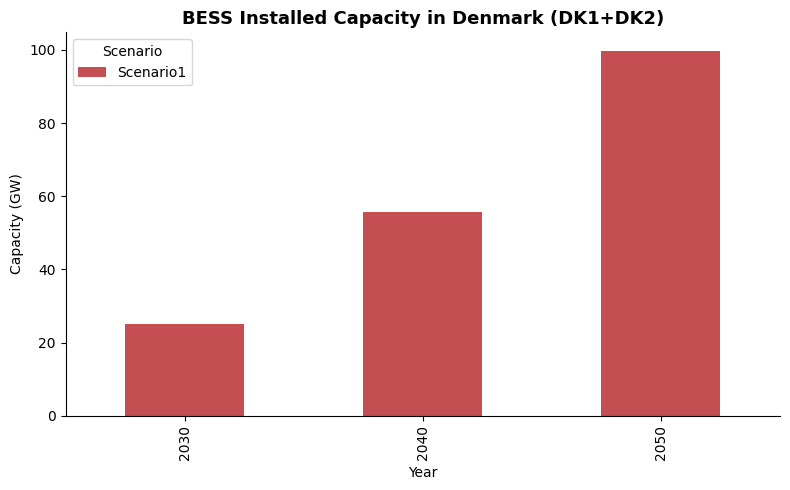

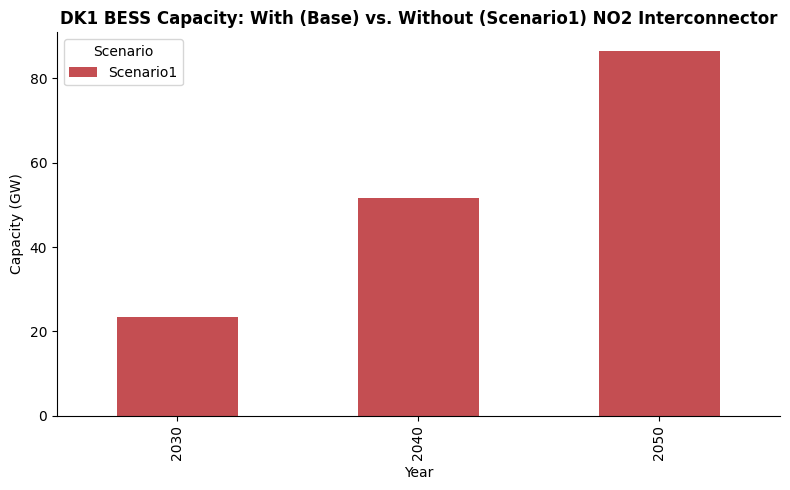

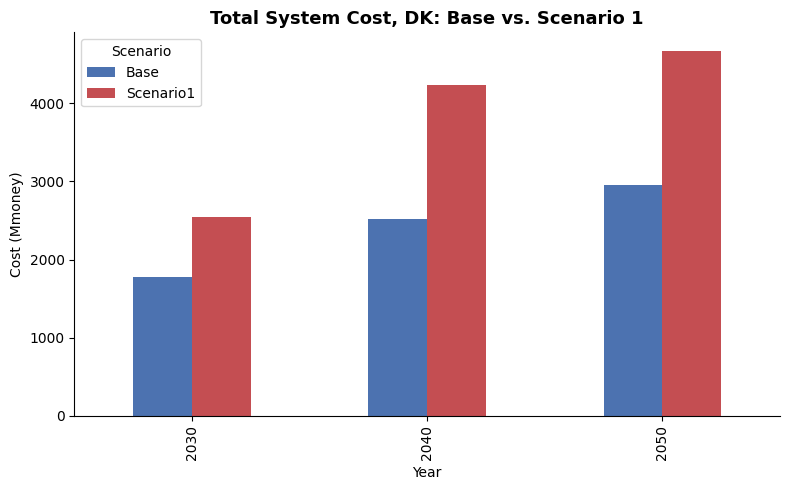

In [9]:
import matplotlib.pyplot as plt

DK_REGIONS = ['DK1', 'DK2']
scenarios = ['Base', 'Scenario1']
colors_scen = {'Base': '#4C72B0', 'Scenario1': '#C44E52'}
BESS_TECH = 'INTRASEASONAL-ELECT-STORAGE'

cap = res.get_result('G_CAP_YCRAF')
pro = res.get_result('PRO_YCRAGF')

common_years = sorted(set(cap.loc[cap['Scenario']=='Base','Year']) &
                       set(cap.loc[cap['Scenario']=='Scenario1','Year']))

# ===========================================================
# PLOT A — BESS capacity build-out, DK (DK1+DK2), Base vs Scenario1
# ===========================================================
bess_cap = cap[(cap['Region'].isin(DK_REGIONS)) & (cap['Technology']==BESS_TECH) & (cap['Year'].isin(common_years))]
pivot = bess_cap.groupby(['Year','Scenario'])['Value'].sum().unstack('Scenario').reindex(common_years)

fig, ax = plt.subplots(figsize=(8,5))
pivot.plot(kind='bar', ax=ax, color=[colors_scen[s] for s in pivot.columns])
ax.set_title('BESS Installed Capacity in Denmark (DK1+DK2)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel(f"Capacity ({bess_cap['Unit'].iloc[0] if len(bess_cap) else '?'})")
ax.spines[['top','right']].set_visible(False)
ax.legend(title='Scenario')
plt.tight_layout()
plt.savefig('a_bess_capacity_dk.png', dpi=200, bbox_inches='tight')
plt.show()

# ===========================================================
# PLOT B — BESS capacity, DK1 only (isolates the interconnector effect)
# ===========================================================
bess_dk1 = cap[(cap['Region']=='DK1') & (cap['Technology']==BESS_TECH) & (cap['Year'].isin(common_years))]
pivot_dk1 = bess_dk1.groupby(['Year','Scenario'])['Value'].sum().unstack('Scenario').reindex(common_years)

fig, ax = plt.subplots(figsize=(8,5))
pivot_dk1.plot(kind='bar', ax=ax, color=[colors_scen[s] for s in pivot_dk1.columns])
ax.set_title('DK1 BESS Capacity: With (Base) vs. Without (Scenario1) NO2 Interconnector', fontsize=12, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel(f"Capacity ({bess_dk1['Unit'].iloc[0] if len(bess_dk1) else '?'})")
ax.spines[['top','right']].set_visible(False)
ax.legend(title='Scenario')
plt.tight_layout()
plt.savefig('b_bess_capacity_dk1.png', dpi=200, bbox_inches='tight')
plt.show()

# ===========================================================
# PLOT C — Total system cost (OBJ_YCR), Base vs Scenario1 — proxy for "cost-efficiency" context
# ===========================================================
obj = res.get_result('OBJ_YCR')
dk_obj = obj[(obj['Region'].isin(DK_REGIONS)) & (obj['Year'].isin(common_years))]
pivot_obj = dk_obj.groupby(['Year','Scenario'])['Value'].sum().unstack('Scenario').reindex(common_years)

fig, ax = plt.subplots(figsize=(8,5))
pivot_obj.plot(kind='bar', ax=ax, color=[colors_scen[s] for s in pivot_obj.columns])
ax.set_title('Total System Cost, DK: Base vs. Scenario 1', fontsize=13, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel(f"Cost ({dk_obj['Unit'].iloc[0] if len(dk_obj) else '?'})")
ax.spines[['top','right']].set_visible(False)
ax.legend(title='Scenario')
plt.tight_layout()
plt.savefig('c_total_cost_dk.png', dpi=200, bbox_inches='tight')
plt.show()

Solar codes found in CURT_YCRAGF: ['GNR_PV_SUN_LS-8-MW_RG2_Y-2030', 'GNR_PV_SUN_LS-8-MW_RG2_Y-2040', 'GNR_PV_SUN_LS-8-MW_RG2_Y-2050']


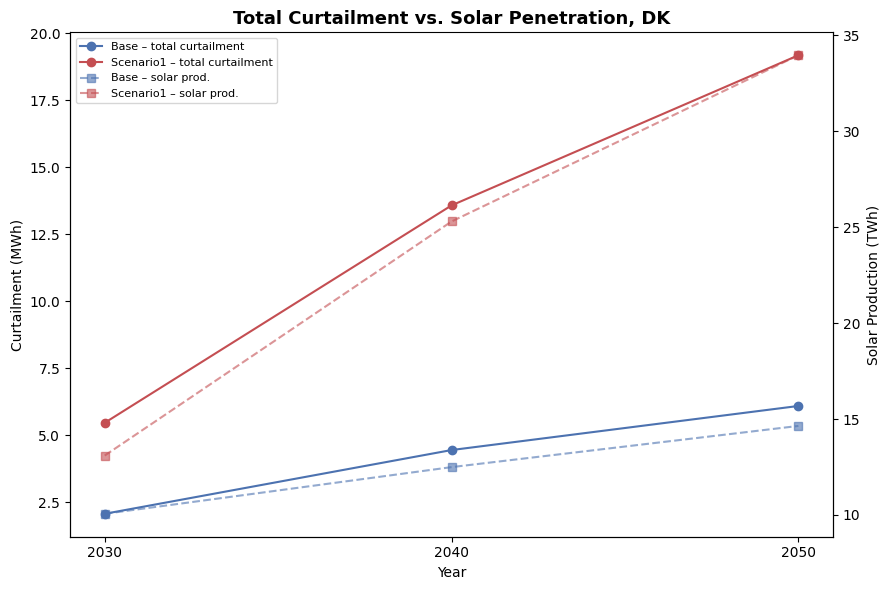

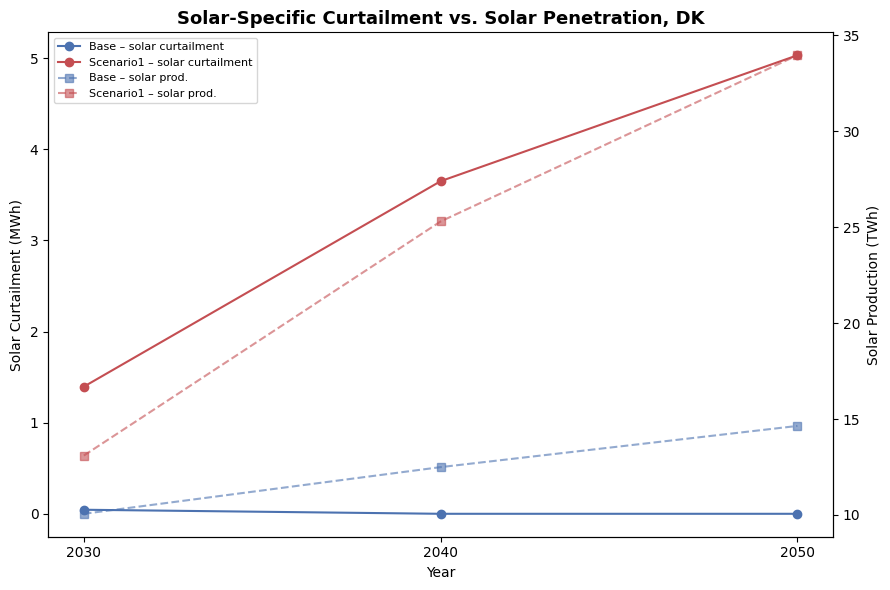

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

curt = res.get_result('CURT_YCRAGF')
pro = res.get_result('PRO_YCRAGF')

# Find solar PV technology code(s) used in raw-code tables like CURT_YCRAGF
solar_codes = [g for g in curt['G'].unique() if 'PV' in g.upper() or 'SOL' in g.upper()]
print('Solar codes found in CURT_YCRAGF:', solar_codes)

# ===========================================================
# Q2 — Curtailment vs. solar penetration: does BESS reduce curtailment?
# ===========================================================

# Curtailment: total DK curtailment (all techs) — raw-code table
dk_curt = curt[(curt['RRR'].isin(DK_REGIONS)) & (curt['Y'].isin(common_years))]
curt_total = dk_curt.groupby(['Y','Scenario'])['Value'].sum().reset_index().rename(columns={'Y':'Year'})

# Curtailment: solar-specific only (more precise for "does BESS reduce solar curtailment")
dk_curt_solar = curt[(curt['RRR'].isin(DK_REGIONS)) & (curt['G'].isin(solar_codes)) & (curt['Y'].isin(common_years))]
curt_solar_total = dk_curt_solar.groupby(['Y','Scenario'])['Value'].sum().reset_index().rename(columns={'Y':'Year'})

# Solar production — friendly-name table
solar = pro[(pro['Region'].isin(DK_REGIONS)) & (pro['Technology']=='SOLAR-PV') & (pro['Year'].isin(common_years))]
solar_total = solar.groupby(['Year','Scenario'])['Value'].sum().reset_index()

# ---- Plot: total curtailment vs solar production ----
fig, ax1 = plt.subplots(figsize=(9,6))
ax2 = ax1.twinx()
for scen in scenarios:
    c = curt_total[curt_total['Scenario']==scen].sort_values('Year')
    s = solar_total[solar_total['Scenario']==scen].sort_values('Year')
    ax1.plot(c['Year'], c['Value'], marker='o', color=colors_scen[scen], label=f'{scen} – total curtailment')
    ax2.plot(s['Year'], s['Value'], marker='s', linestyle='--', color=colors_scen[scen], alpha=0.6, label=f'{scen} – solar prod.')

ax1.set_ylabel('Curtailment (MWh)'); ax2.set_ylabel('Solar Production (TWh)')
ax1.set_xlabel('Year')
ax1.set_title('Total Curtailment vs. Solar Penetration, DK', fontsize=13, fontweight='bold')
l1,lb1 = ax1.get_legend_handles_labels(); l2,lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, fontsize=8, loc='upper left')
ax1.spines[['top']].set_visible(False)
plt.tight_layout()
plt.savefig('q2a_total_curtailment_vs_solar.png', dpi=200, bbox_inches='tight')
plt.show()

# ---- Plot: solar-specific curtailment vs solar production (more precise) ----
fig, ax1 = plt.subplots(figsize=(9,6))
ax2 = ax1.twinx()
for scen in scenarios:
    c = curt_solar_total[curt_solar_total['Scenario']==scen].sort_values('Year')
    s = solar_total[solar_total['Scenario']==scen].sort_values('Year')
    ax1.plot(c['Year'], c['Value'], marker='o', color=colors_scen[scen], label=f'{scen} – solar curtailment')
    ax2.plot(s['Year'], s['Value'], marker='s', linestyle='--', color=colors_scen[scen], alpha=0.6, label=f'{scen} – solar prod.')

ax1.set_ylabel('Solar Curtailment (MWh)'); ax2.set_ylabel('Solar Production (TWh)')
ax1.set_xlabel('Year')
ax1.set_title('Solar-Specific Curtailment vs. Solar Penetration, DK', fontsize=13, fontweight='bold')
l1,lb1 = ax1.get_legend_handles_labels(); l2,lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, fontsize=8, loc='upper left')
ax1.spines[['top']].set_visible(False)
plt.tight_layout()
plt.savefig('q2b_solar_curtailment_vs_solar.png', dpi=200, bbox_inches='tight')
plt.show()

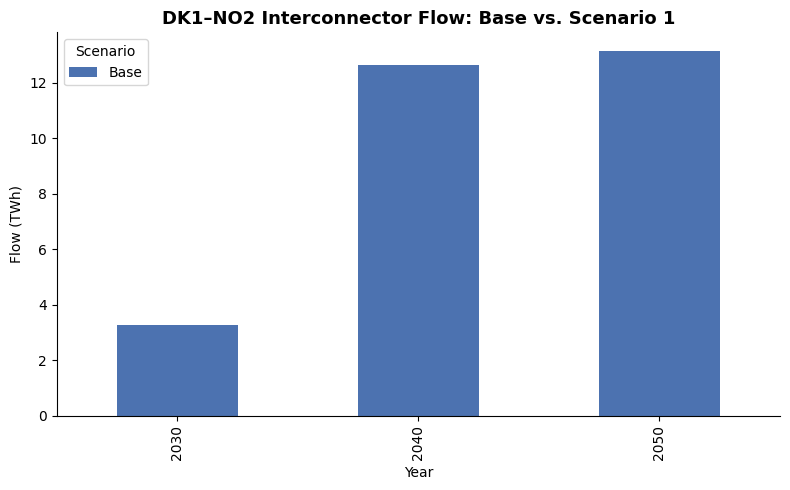

In [11]:
import matplotlib.pyplot as plt

dk_no2 = flow[
    ((flow['From']=='DK1') & (flow['To']=='NO2')) |
    ((flow['From']=='NO2') & (flow['To']=='DK1'))
]
dk_no2 = dk_no2[dk_no2['Year'].isin(common_years)]

flow_total = dk_no2.groupby(['Year','Scenario'])['Value'].sum().reset_index()
pivot_flow = flow_total.pivot(index='Year', columns='Scenario', values='Value').reindex(common_years).fillna(0)

fig, ax = plt.subplots(figsize=(8,5))
pivot_flow.plot(kind='bar', ax=ax, color=[colors_scen.get(s, 'gray') for s in pivot_flow.columns])
ax.set_title('DK1–NO2 Interconnector Flow: Base vs. Scenario 1', fontsize=13, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Flow (TWh)')
ax.spines[['top','right']].set_visible(False)
ax.legend(title='Scenario')
plt.tight_layout()
plt.savefig('q3_dk1_no2_flow.png', dpi=200, bbox_inches='tight')
plt.show()